# SEAS 8520 - Lecture 2: MLP Architecture and Core Concepts

**Reference:** Chollet, *Deep Learning with Python*, 2nd Edition, Chapter 2 (pp. 27-48)

This notebook covers tensor fundamentals, tensor operations, and building/training a multi-layer perceptron (MLP) on MNIST using TensorFlow/Keras.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

# GPU / accelerator detection
# Works on Apple Silicon (Metal), NVIDIA (CUDA), and Google Colab
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) detected: {[g.name for g in gpus]}")
    # Allow memory growth to avoid allocating all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected. Using CPU.")
    print("  - Apple Silicon: pip install tensorflow-metal")
    print("  - Google Colab: Runtime > Change runtime type > GPU")

TensorFlow version: 2.21.0
NumPy version: 2.4.6
No GPU detected. Using CPU.
  - Apple Silicon: pip install tensorflow-metal
  - Google Colab: Runtime > Change runtime type > GPU


## 1. Tensors and Data Representations

Tensors are the fundamental data structure in deep learning. They are multi-dimensional arrays (generalizations of matrices) with a fixed number of axes (rank) and a data type. We build intuition by constructing tensors of increasing dimensionality.

In [2]:
# Scalar (0D tensor) - a single number
scalar = np.array(42)
print("Scalar:")
print(f"  Value: {scalar}")
print(f"  ndim: {scalar.ndim}, shape: {scalar.shape}, dtype: {scalar.dtype}")
print()

Scalar:
  Value: 42
  ndim: 0, shape: (), dtype: int64



In [3]:
# Vector (1D tensor) - a sequence of numbers
vector = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
print("Vector:")
print(f"  Value: {vector}")
print(f"  ndim: {vector.ndim}, shape: {vector.shape}, dtype: {vector.dtype}")
print()

Vector:
  Value: [1. 2. 3. 4. 5.]
  ndim: 1, shape: (5,), dtype: float64



In [4]:
# Matrix (2D tensor) - a table of numbers
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print("Matrix:")
print(f"  Value:\n{matrix}")
print(f"  ndim: {matrix.ndim}, shape: {matrix.shape}, dtype: {matrix.dtype}")
print()

Matrix:
  Value:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
  ndim: 2, shape: (3, 3), dtype: int64



In [5]:
# 3D tensor - e.g., a batch of matrices (common for time-series or text data)
tensor_3d = np.random.randint(0, 10, size=(3, 4, 5))  # 3 samples, 4 timesteps, 5 features
print("3D Tensor:")
print(f"  ndim: {tensor_3d.ndim}, shape: {tensor_3d.shape}, dtype: {tensor_3d.dtype}")
print(f"  First sample:\n{tensor_3d[0]}")
print()

3D Tensor:
  ndim: 3, shape: (3, 4, 5), dtype: int64
  First sample:
[[8 5 8 5 0]
 [8 7 6 5 2]
 [8 4 6 9 9]
 [5 4 3 4 5]]



In [6]:
# Tensor slicing examples
# Batch slicing: select specific samples
print("Batch slicing (first 2 samples):")
print(f"  Shape: {tensor_3d[:2].shape}")

# Channel/feature slicing: select specific features across all samples and timesteps
print("Channel slicing (features 1-3):")
print(f"  Shape: {tensor_3d[:, :, 1:4].shape}")

# Mixed slicing: sample 0, timesteps 1-2, all features
print("Mixed slice [0, 1:3, :]:")
print(f"  Shape: {tensor_3d[0, 1:3, :].shape}")
print(f"  Values:\n{tensor_3d[0, 1:3, :]}")

Batch slicing (first 2 samples):
  Shape: (2, 4, 5)
Channel slicing (features 1-3):
  Shape: (3, 4, 3)
Mixed slice [0, 1:3, :]:
  Shape: (2, 5)
  Values:
[[8 7 6 5 2]
 [8 4 6 9 9]]


Single MNIST digit shape: (28, 28)
Pixel value range: [0, 255]


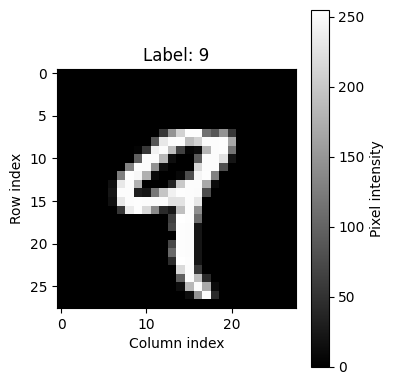

In [7]:
# Visualize a sample MNIST digit as a 2D tensor
(train_images, train_labels), _ = keras.datasets.mnist.load_data()

digit = train_images[4]  # A single 28x28 grayscale image
print(f"Single MNIST digit shape: {digit.shape}")
print(f"Pixel value range: [{digit.min()}, {digit.max()}]")

plt.figure(figsize=(4, 4))
plt.imshow(digit, cmap='gray')
plt.title(f"Label: {train_labels[4]}")
plt.colorbar(label='Pixel intensity')
plt.xlabel('Column index')
plt.ylabel('Row index')
plt.tight_layout()
plt.show()

## 2. Tensor Operations

Neural networks are composed of chains of tensor operations: element-wise functions, broadcasting, dot products, and reshaping. These operations form the computational backbone of every layer in a network.

In [8]:
# Element-wise operations
a = np.array([1.0, -2.0, 3.0, -4.0])
b = np.array([2.0, 3.0, 1.0, 5.0])

# Addition
print(f"a + b = {a + b}")

# Multiplication (Hadamard product)
print(f"a * b = {a * b}")

# ReLU: max(0, x) - the most common activation function
relu_a = np.maximum(0, a)
print(f"relu(a) = {relu_a}")

a + b = [3. 1. 4. 1.]
a * b = [  2.  -6.   3. -20.]
relu(a) = [1. 0. 3. 0.]


In [9]:
# Broadcasting: adding a bias vector to a matrix
# This is exactly what happens in a Dense layer: output = dot(input, W) + b
X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])  # Shape (3, 3) - 3 samples, 3 features

bias = np.array([10, 20, 30])  # Shape (3,) - one bias per output neuron

# bias is broadcast across rows (each sample gets the same bias added)
result = X + bias
print(f"X shape: {X.shape}")
print(f"bias shape: {bias.shape}")
print(f"X + bias (broadcast):\n{result}")

X shape: (3, 3)
bias shape: (3,)
X + bias (broadcast):
[[11 22 33]
 [14 25 36]
 [17 28 39]]


In [10]:
# Dot product and matrix multiplication
# This is the core operation of Dense layers
x = np.array([1, 2, 3])  # Input vector
W = np.array([[0.1, 0.2],
              [0.3, 0.4],
              [0.5, 0.6]])  # Weight matrix (3 inputs, 2 outputs)

# Vector-matrix dot product
output = np.dot(x, W)
print(f"x shape: {x.shape}, W shape: {W.shape}")
print(f"np.dot(x, W) = {output}  (shape: {output.shape})")

# Batch matrix multiplication
X_batch = np.random.randn(5, 3)  # 5 samples, 3 features
output_batch = np.dot(X_batch, W)
print(f"\nBatch: X shape {X_batch.shape} dot W shape {W.shape} = output shape {output_batch.shape}")

x shape: (3,), W shape: (3, 2)
np.dot(x, W) = [2.2 2.8]  (shape: (2,))

Batch: X shape (5, 3) dot W shape (3, 2) = output shape (5, 2)


In [11]:
# Tensor reshaping and transposing
x = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"Original shape: {x.shape}")

# Reshape to different configurations
reshaped_1 = x.reshape(6,)      # Flatten to 1D
reshaped_2 = x.reshape(3, 2)    # 3 rows, 2 cols
reshaped_3 = x.reshape(1, 6)    # 1 row, 6 cols (row vector)

print(f"Reshaped to (6,): {reshaped_1}")
print(f"Reshaped to (3,2):\n{reshaped_2}")
print(f"Reshaped to (1,6): {reshaped_3}")

# Key property: reshaping preserves total element count
total_elements = x.size
print(f"\nTotal elements preserved: {total_elements} == {reshaped_1.size} == {reshaped_2.size} == {reshaped_3.size}")

# Transpose
print(f"\nTranspose of x (shape {x.shape}): shape {x.T.shape}")
print(f"x.T:\n{x.T}")

Original shape: (2, 3)
Reshaped to (6,): [1 2 3 4 5 6]
Reshaped to (3,2):
[[1 2]
 [3 4]
 [5 6]]
Reshaped to (1,6): [[1 2 3 4 5 6]]

Total elements preserved: 6 == 6 == 6 == 6

Transpose of x (shape (2, 3)): shape (3, 2)
x.T:
[[1 4]
 [2 5]
 [3 6]]


## 3. Loading and Exploring MNIST

MNIST is the standard benchmark for introductory classification. It contains 70,000 grayscale images of handwritten digits (28x28 pixels). We preprocess by normalizing to [0,1] and one-hot encoding labels for categorical cross-entropy loss.

In [12]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

print("Raw data shapes:")
print(f"  train_images: {train_images.shape}, dtype: {train_images.dtype}")
print(f"  train_labels: {train_labels.shape}, dtype: {train_labels.dtype}")
print(f"  test_images:  {test_images.shape}, dtype: {test_images.dtype}")
print(f"  test_labels:  {test_labels.shape}, dtype: {test_labels.dtype}")
print(f"\nPixel value range: [{train_images.min()}, {train_images.max()}]")
print(f"Label values: {np.unique(train_labels)}")

Raw data shapes:
  train_images: (60000, 28, 28), dtype: uint8
  train_labels: (60000,), dtype: uint8
  test_images:  (10000, 28, 28), dtype: uint8
  test_labels:  (10000,), dtype: uint8

Pixel value range: [0, 255]
Label values: [0 1 2 3 4 5 6 7 8 9]


In [13]:
# Normalize pixel values to [0, 1] range (float32)
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print(f"After normalization:")
print(f"  dtype: {train_images.dtype}")
print(f"  Pixel range: [{train_images.min():.1f}, {train_images.max():.1f}]")

# One-hot encode labels
# Before: label = 7 (integer)
# After:  label = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0] (10-dim vector)
train_labels_onehot = to_categorical(train_labels, 10)
test_labels_onehot = to_categorical(test_labels, 10)

print(f"\nOne-hot encoded labels shape: {train_labels_onehot.shape}")
print(f"Example - digit {train_labels[0]}: {train_labels_onehot[0]}")

After normalization:
  dtype: float32
  Pixel range: [0.0, 1.0]

One-hot encoded labels shape: (60000, 10)
Example - digit 5: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


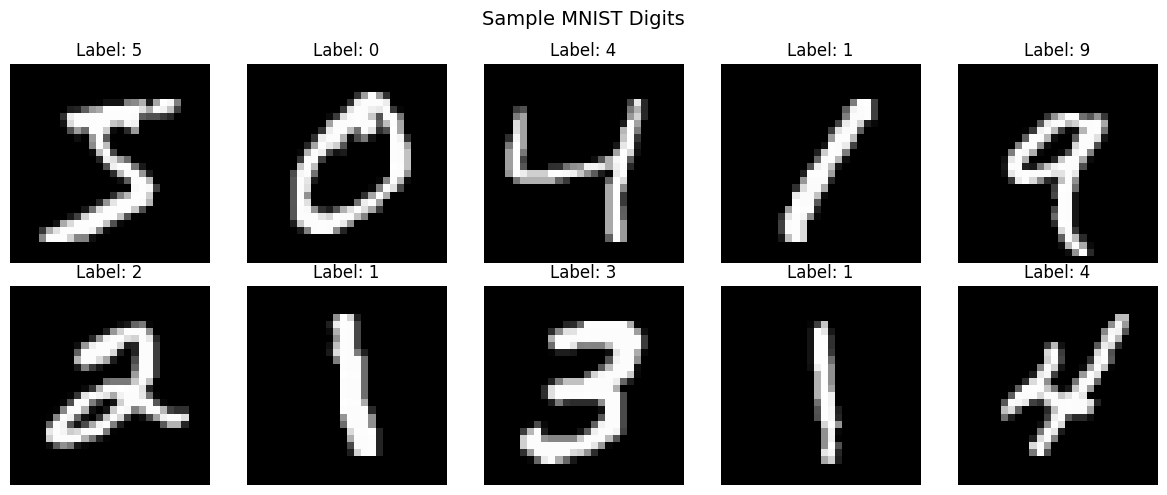

In [14]:
# Display a grid of 10 sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(f"Label: {train_labels[i]}", fontsize=12)
    ax.axis('off')
plt.suptitle("Sample MNIST Digits", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Building an MLP in Keras

We construct a Sequential model with two hidden layers. The Flatten layer converts each 28x28 image into a 784-dimensional vector. Each Dense layer performs: output = activation(dot(input, W) + b). The final softmax layer outputs a probability distribution over 10 classes.

In [15]:
# Build the MLP
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),       # 28*28 = 784 inputs
    layers.Dense(128, activation='relu'),        # Hidden layer 1
    layers.Dense(64, activation='relu'),         # Hidden layer 2
    layers.Dense(10, activation='softmax')       # Output layer (10 classes)
])

model.summary()

/opt/homebrew/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Manually verify parameter counts
# Dense layer params = (input_dim * output_dim) + output_dim (for bias)
layer1_params = 784 * 128 + 128     # Flatten(784) -> Dense(128)
layer2_params = 128 * 64 + 64       # Dense(128) -> Dense(64)
layer3_params = 64 * 10 + 10        # Dense(64) -> Dense(10)
total_params = layer1_params + layer2_params + layer3_params

print("Parameter count verification:")
print(f"  Layer 1 (784 -> 128): {layer1_params:,}")
print(f"  Layer 2 (128 -> 64):  {layer2_params:,}")
print(f"  Layer 3 (64 -> 10):   {layer3_params:,}")
print(f"  Total:                {total_params:,}")
print(f"\n  Expected: 109,386")
assert total_params == 109386, "Parameter count mismatch!"

Parameter count verification:
  Layer 1 (784 -> 128): 100,480
  Layer 2 (128 -> 64):  8,256
  Layer 3 (64 -> 10):   650
  Total:                109,386

  Expected: 109,386


In [17]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled with Adam optimizer and categorical cross-entropy loss.")

Model compiled with Adam optimizer and categorical cross-entropy loss.


## 5. Training the Model

We train for 10 epochs with a batch size of 128 and hold out 15% of training data for validation. The history object stores per-epoch metrics, which we plot to assess convergence and detect overfitting.

In [18]:
# Train the model
history = model.fit(
    train_images,
    train_labels_onehot,
    epochs=10,
    batch_size=128,
    validation_split=0.15,
    verbose=1
)

Epoch 1/10


  1/399 ━━━━━━━━━━━━━━━━━━━━ 1:39 250ms/step - accuracy: 0.0859 - loss: 2.3807

 69/399 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 0.5508 - loss: 1.5232  

143/399 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.6739 - loss: 1.1337

218/399 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.7312 - loss: 0.9408

...

151/399 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.9924 - loss: 0.0272

227/399 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - accuracy: 0.9925 - loss: 0.0260

301/399 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.9927 - loss: 0.0253

377/399 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - accuracy: 0.9927 - loss: 0.0250

399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - accuracy: 0.9928 - loss: 0.0244 - val_accuracy: 0.9772 - val_loss: 0.0880


Saved training_curves.pdf to /Users/wale/Desktop/GWU_SEAS_8520_A6A_Summer2026/lecture_notes/figures


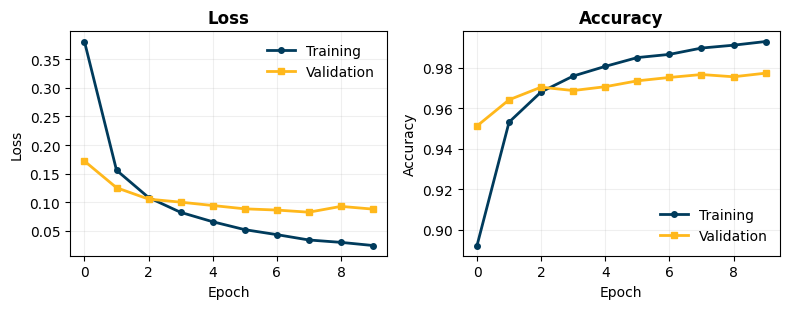

In [19]:
# Plot training vs validation loss and accuracy
# Also save to figures/ for the lecture slides
import os

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.2))

gwblue = '#003B5C'
gwgold = '#FFB81C'

ax1.plot(history.history['loss'], color=gwblue, linewidth=2, marker='o', markersize=4, label='Training')
ax1.plot(history.history['val_loss'], color=gwgold, linewidth=2, marker='s', markersize=4, label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss', fontweight='bold')
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.2)

ax2.plot(history.history['accuracy'], color=gwblue, linewidth=2, marker='o', markersize=4, label='Training')
ax2.plot(history.history['val_accuracy'], color=gwgold, linewidth=2, marker='s', markersize=4, label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy', fontweight='bold')
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.2)

plt.tight_layout()

# Save for lecture slides
figures_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'figures')
os.makedirs(figures_dir, exist_ok=True)
fig.savefig(os.path.join(figures_dir, 'training_curves.pdf'), bbox_inches='tight', dpi=150)
print(f"Saved training_curves.pdf to {figures_dir}")

plt.show()

In [20]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_images, test_labels_onehot, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Loss: 0.0827
Test Accuracy: 0.9776 (97.76%)


## 6. Understanding Predictions

The softmax output layer produces a probability distribution over all 10 classes for each input. We inspect individual predictions, visualize correct/incorrect classifications, and compute a confusion matrix to identify systematic errors.

In [21]:
# Get predictions on the test set
predictions = model.predict(test_images, verbose=0)
print(f"Predictions shape: {predictions.shape}")
print(f"Each prediction is a probability distribution that sums to 1.0")

# Show softmax output for a single example
sample_idx = 0
print(f"\nSample index {sample_idx} - True label: {test_labels[sample_idx]}")
print(f"Predicted label: {np.argmax(predictions[sample_idx])}")
print(f"\nClass probabilities:")
for digit, prob in enumerate(predictions[sample_idx]):
    bar = '#' * int(prob * 50)
    print(f"  Digit {digit}: {prob:.6f} {bar}")
print(f"  Sum: {predictions[sample_idx].sum():.6f}")

Predictions shape: (10000, 10)
Each prediction is a probability distribution that sums to 1.0

Sample index 0 - True label: 7
Predicted label: 7

Class probabilities:
  Digit 0: 0.000000 
  Digit 1: 0.000001 
  Digit 2: 0.000095 
  Digit 3: 0.000499 
  Digit 4: 0.000000 
  Digit 5: 0.000001 
  Digit 6: 0.000000 
  Digit 7: 0.999398 #################################################
  Digit 8: 0.000003 
  Digit 9: 0.000003 
  Sum: 1.000000


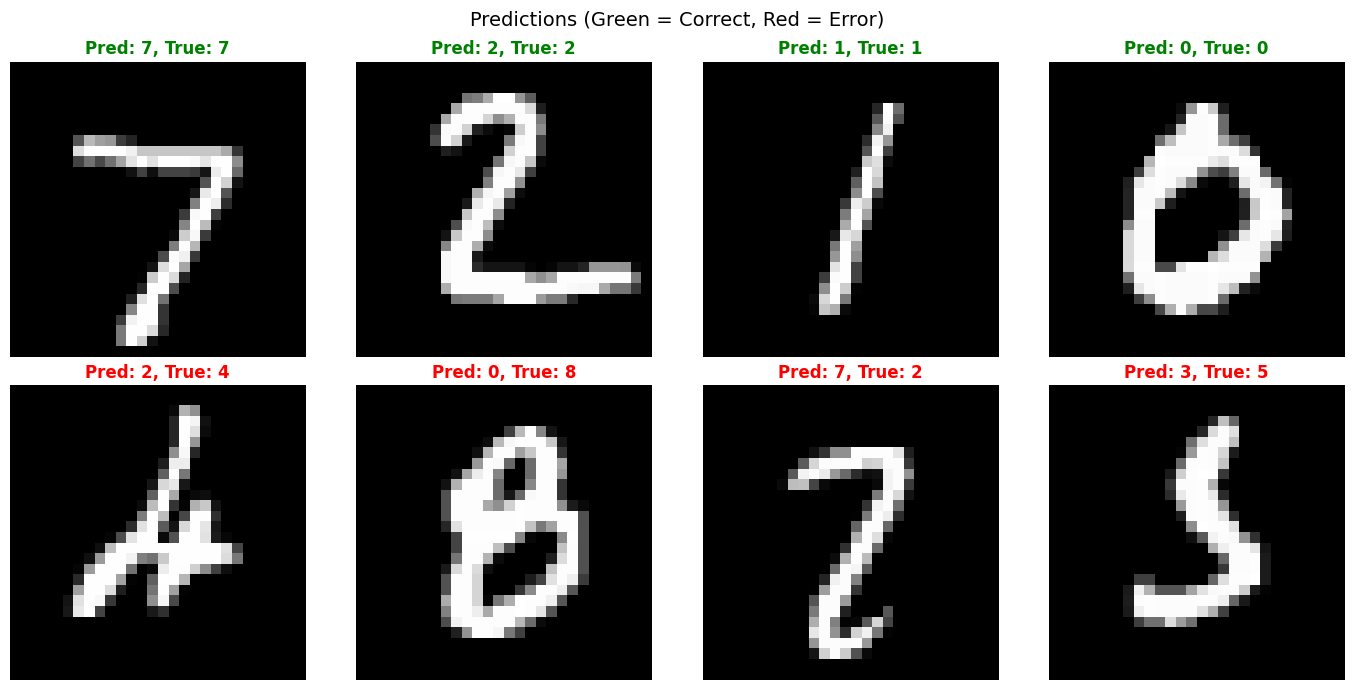

Total errors on test set: 224 / 10000


In [22]:
# Display 8 test images with predicted vs actual labels
# Highlight errors in red
predicted_labels = np.argmax(predictions, axis=1)

# Find some correct and incorrect predictions for display
incorrect_indices = np.where(predicted_labels != test_labels)[0]
correct_indices = np.where(predicted_labels == test_labels)[0]

# Mix: 4 correct, 4 incorrect (if available)
display_indices = list(correct_indices[:4]) + list(incorrect_indices[:4])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    idx = display_indices[i]
    ax.imshow(test_images[idx], cmap='gray')
    pred = predicted_labels[idx]
    true = test_labels[idx]
    is_correct = (pred == true)
    color = 'green' if is_correct else 'red'
    ax.set_title(f"Pred: {pred}, True: {true}", color=color, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Predictions (Green = Correct, Red = Error)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total errors on test set: {len(incorrect_indices)} / {len(test_labels)}")

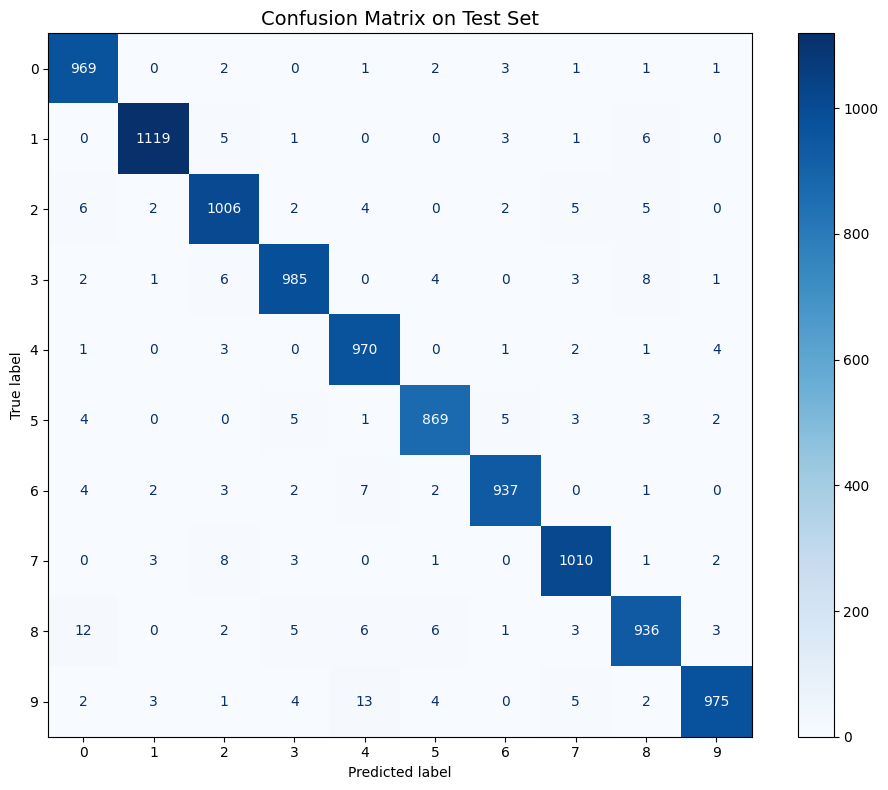

Most confused pair: true=9, predicted=4 (13 times)


In [23]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, predicted_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

# Identify most confused pairs
np.fill_diagonal(cm, 0)  # Zero out diagonal to find off-diagonal max
max_confusion = np.unravel_index(cm.argmax(), cm.shape)
print(f"Most confused pair: true={max_confusion[0]}, predicted={max_confusion[1]} ({cm[max_confusion]} times)")

## 7. Experimenting with Architecture

We compare three architectures to build intuition about capacity vs. performance. A smaller network may underfit, while a deeper/wider network may achieve better accuracy but with more parameters and potential overfitting risk.

In [24]:
def build_and_train(architecture_name, hidden_layers, epochs=10, batch_size=128):
    """Build, compile, train, and evaluate an MLP with given hidden layers."""
    # Build model
    model_layers = [layers.Flatten(input_shape=(28, 28))]
    for units in hidden_layers:
        model_layers.append(layers.Dense(units, activation='relu'))
    model_layers.append(layers.Dense(10, activation='softmax'))
    
    m = keras.Sequential(model_layers)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train
    print(f"\n{'='*60}")
    print(f"Training: {architecture_name}")
    print(f"Hidden layers: {hidden_layers}")
    print(f"Total parameters: {m.count_params():,}")
    print(f"{'='*60}")
    
    h = m.fit(train_images, train_labels_onehot,
              epochs=epochs, batch_size=batch_size,
              validation_split=0.15, verbose=0)
    
    # Evaluate
    test_loss, test_acc = m.evaluate(test_images, test_labels_onehot, verbose=0)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    return architecture_name, hidden_layers, m.count_params(), test_acc

In [25]:
# Train three different architectures
results = []

# Small model: single narrow hidden layer
results.append(build_and_train("Small", [32]))

# Baseline model: same as Section 4
results.append(build_and_train("Baseline", [128, 64]))

# Deeper/wider model
results.append(build_and_train("Deep", [256, 128, 64]))


Training: Small
Hidden layers: [32]
Total parameters: 25,450


/opt/homebrew/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Test Accuracy: 0.9617

Training: Baseline
Hidden layers: [128, 64]
Total parameters: 109,386


Test Accuracy: 0.9778

Training: Deep
Hidden layers: [256, 128, 64]
Total parameters: 242,762


Test Accuracy: 0.9751


In [26]:
# Print comparison table
print("\n" + "="*70)
print(f"{'Architecture':<15} {'Hidden Layers':<20} {'Parameters':<15} {'Test Accuracy':<15}")
print("-"*70)
for name, layers_cfg, params, acc in results:
    layers_str = str(layers_cfg)
    print(f"{name:<15} {layers_str:<20} {params:<15,} {acc:<15.4f}")
print("="*70)

# Identify best architecture
best = max(results, key=lambda x: x[3])
print(f"\nBest architecture: {best[0]} with test accuracy {best[3]:.4f}")


Architecture    Hidden Layers        Parameters      Test Accuracy  
----------------------------------------------------------------------
Small           [32]                 25,450          0.9617         
Baseline        [128, 64]            109,386         0.9778         
Deep            [256, 128, 64]       242,762         0.9751         

Best architecture: Baseline with test accuracy 0.9778
